# Sobol sensitivity indices

A four-axis injection-dispersion fixture is the same one [notebook 04](https://astro-tools.github.io/gmat-sweep/examples/04_monte_carlo_dispersion/) Monte-Carlos. A Saltelli/Sobol design teases that cube apart into per-parameter contributions: how much of the arrival-miss variance is driven by each axis on its own (`S1`), how much by all interactions involving it (`ST`), and how much by every pairwise interaction (`S2`).

[`sobol_sample`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.sobol_sample) builds the Saltelli design as an explicit-row DataFrame; [`sweep(samples=...)`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.sweep) executes one row per run; [`sobol_analyze`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.sobol_analyze) runs the SALib analysis on the result.

**Prerequisites.** A local GMAT install (R2026a is the primary development target; see [Supported versions](https://astro-tools.github.io/gmat-sweep/supported-versions/)), `pip install gmat-sweep[examples]` for the matplotlib dependency, and `pip install gmat-sweep[sensitivity]` for SALib.

## Set up the run

Resolve the GMAT install once and confirm the script that ships next to this notebook is where we expect it. The script is the same parking-orbit-plus-`Inj`-burn-plus-`CoastTime` fixture that notebook 04 uses; the four perturbed axes match.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from gmat_run import locate_gmat

from gmat_sweep import sobol_analyze, sobol_sample, sweep

install = locate_gmat()
script_path = Path("injection_dispersion.script").resolve()

print(f"GMAT version: {install.version}")
print(f"Script:       {script_path.name}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       injection_dispersion.script
Exists:       True


## Define the perturbations

The four perturbed axes — same as notebook 04, just narrowed slightly so the per-axis ranges land in a regime where the Sobol indices are visibly non-trivial:

- `CoastTime.Value` — normal, mean 600 s, 1-sigma 30 s. The launch-time slip on the parking orbit before the burn fires.
- `Inj.Element1/2/3` — normal, mean (1.0, 0.0, 0.0) km/s, 1-sigma 5 m/s on each axis. The (V, N, B) components of the injection delta-V.

Each `DistSpec` entry is the same shorthand [`monte_carlo`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.monte_carlo) accepts. `sobol_sample` lifts the unit-cube Saltelli design through each axis's marginal via `to_rv_frozen(...).ppf(...)`, so non-uniform shapes work without re-encoding the problem in SALib's own `dists` knob.

In [2]:
SEED = 20260507

perturb = {
    "CoastTime.Value": ("normal", 600.0, 30.0),
    "Inj.Element1": ("normal", 1.0, 0.005),
    "Inj.Element2": ("normal", 0.0, 0.005),
    "Inj.Element3": ("normal", 0.0, 0.005),
}

## Build the Saltelli design

`n=64` is the Saltelli base sample size (a power of two, per SALib's recommendation). With `D=4` parameters and `calc_second_order=True` (the default), the row count is `n * (2*D + 2) = 64 * 10 = 640`. Two calls at the same `(perturb, n, seed, calc_second_order)` produce bit-equal DataFrames.

In [3]:
SOBOL_N = 64

design = sobol_sample(perturb, n=SOBOL_N, seed=SEED)
print(f"Design rows: {len(design)}")
print(f"Columns:     {list(design.columns)}")
design.head()

Design rows: 640
Columns:     ['CoastTime.Value', 'Inj.Element1', 'Inj.Element2', 'Inj.Element3']


,CoastTime.Value,Inj.Element1,Inj.Element2,Inj.Element3
0,579.600686,1.003320,0.011043,0.001204
1,669.052335,1.003320,0.011043,0.001204
2,579.600686,0.995569,0.011043,0.001204
3,579.600686,1.003320,0.001904,0.001204
4,579.600686,1.003320,0.011043,0.000152


## Run the sweep over the design

Pass the explicit-row design through [`sweep(samples=...)`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.sweep). Each row's column values land as per-run overrides; the default `LocalJoblibPool` dispatches the 640 runs in parallel.

In [4]:
df = sweep(
    script_path,
    samples=design,
    progress=False,
)
df["__status"].value_counts()

__status
ok    7680
Name: count, dtype: int64

## Define the per-run scalar

Sobol analysis collapses the (run_id, time)-MultiIndexed sweep frame to one scalar per run. Pick **arrival miss distance from the empirical mean** — the same canonical 1-D summary notebook 04 uses for its histogram.

The callable receives `df` and returns a Series indexed by `run_id` of length 640. SALib expects this Y vector in the order the design was built; preserving the `run_id` index keeps the contract obvious at the call site.

In [5]:
import pandas as pd


def miss_distance(df_in):
    final = df_in.groupby(level="run_id").last()
    arrivals = final[["Sat.X", "Sat.Y", "Sat.Z"]].to_numpy()
    return np.linalg.norm(arrivals - arrivals.mean(axis=0), axis=1)


# Sanity check: one scalar per run, in run_id order.
y = pd.Series(
    miss_distance(df),
    index=df.groupby(level="run_id").last().index,
    name="miss_km",
)
print(f"Y vector length: {len(y)}")
print(f"Y range (km):    {y.min():.3f} to {y.max():.3f}")

Y vector length: 640
Y range (km):    3.277 to 696.264


## Compute the indices

[`sobol_analyze`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.sobol_analyze) runs the SALib analysis on `Y` and returns a tidy long DataFrame: one row per `(kind, param_a, param_b)` triple. `kind` is `"S1"`, `"ST"`, or `"S2"`; `value` is the Sobol index; `conf` is the 95% bootstrap confidence half-width.

In [6]:
indices = sobol_analyze(df, perturb, metric=lambda d: y, seed=SEED)
indices

,kind,param_a,param_b,value,conf
0,S1,CoastTime.Value,NaN,0.969635,0.357048
1,S1,Inj.Element1,NaN,0.001635,0.002600
2,S1,Inj.Element2,NaN,0.000110,0.000381
3,S1,Inj.Element3,NaN,-0.002945,0.011532
4,ST,CoastTime.Value,NaN,0.995872,0.227900
5,ST,Inj.Element1,NaN,0.000050,0.000051
6,ST,Inj.Element2,NaN,0.000002,0.000002
7,ST,Inj.Element3,NaN,0.001642,0.000647
8,S2,CoastTime.Value,Inj.Element1,0.053627,0.541155
9,S2,CoastTime.Value,Inj.Element2,0.055939,0.540005


## Plot the first-order and total-order indices

`S1` is the variance fraction explained by varying that parameter alone with the others fixed; `ST` includes that parameter plus all interactions involving it. The gap between `S1` and `ST` for a parameter is roughly the variance attributable to its interactions — a useful heuristic for whether second-order analysis is worth chasing.

Errors bars are SALib's 95% bootstrap confidence half-width.

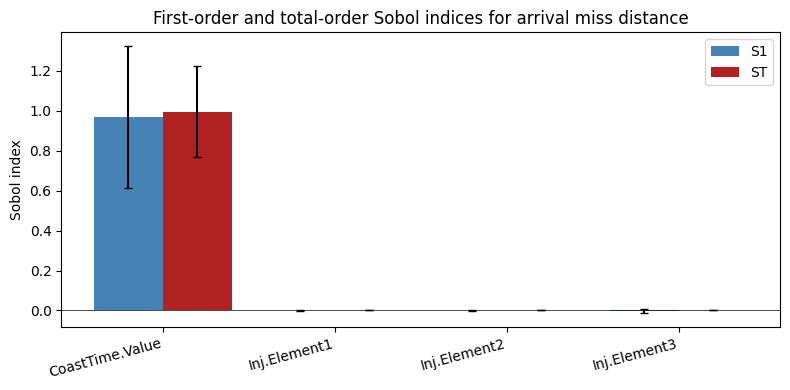

In [7]:
first_order = indices[indices["kind"] == "S1"].reset_index(drop=True)
total_order = indices[indices["kind"] == "ST"].reset_index(drop=True)

x = np.arange(len(first_order))
width = 0.4

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    x - width / 2,
    first_order["value"],
    width,
    yerr=first_order["conf"],
    label="S1",
    color="steelblue",
    capsize=3,
)
ax.bar(
    x + width / 2,
    total_order["value"],
    width,
    yerr=total_order["conf"],
    label="ST",
    color="firebrick",
    capsize=3,
)
ax.set_xticks(x)
ax.set_xticklabels(first_order["param_a"], rotation=15, ha="right")
ax.set_ylabel("Sobol index")
ax.set_title("First-order and total-order Sobol indices for arrival miss distance")
ax.axhline(0.0, color="black", linewidth=0.5)
ax.legend()
fig.tight_layout()
plt.show()

## Where to next

- **Variance budget under a plain MC.** [Notebook 04](https://astro-tools.github.io/gmat-sweep/examples/04_monte_carlo_dispersion/) runs a 1000-run plain Monte Carlo over the same four-axis cube — the histogram is the unconditional dispersion that Sobol decomposes here.
- **Second-order interactions.** `indices[indices["kind"] == "S2"]` carries the pairwise interaction indices already computed by `sobol_analyze` (the default `calc_second_order=True`); a heatmap over the `(param_a, param_b)` upper triangle is one cell away.
- **Sensitivity reference.** [Sensitivity](https://astro-tools.github.io/gmat-sweep/sensitivity/) walks through the Saltelli design size formula and the relationship to the sample-and-analyse split documented in `SALib`.